In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold,cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Predicting a song's streams based on musical features

this notebook is merely just me remembering how to do ML because I got off track and forgot the basics. this is mostly mediocre, but i'm learning from my mistakes.

## reading and pre-processing

In [2]:
df = pd.read_csv("spotify_alltime_top100_songs.csv")

In [3]:
df.head()

,alltime_rank,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
0,1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
1,2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100
2,3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100
3,4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Spotify All-Time Most Streamed Top 100
4,5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09,Spotify All-Time Most Streamed Top 100


In [4]:
df.shape

(100, 14)

In [5]:
df.isna().sum()

alltime_rank              0
song_title                0
artist                    0
total_streams_billions    0
primary_genre             0
bpm                       0
release_year              0
artist_country            0
explicit                  0
danceability              0
energy                    0
valence                   0
acousticness              0
dataset_part              0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   alltime_rank            100 non-null    int64  
 1   song_title              100 non-null    str    
 2   artist                  100 non-null    str    
 3   total_streams_billions  100 non-null    float64
 4   primary_genre           100 non-null    str    
 5   bpm                     100 non-null    int64  
 6   release_year            100 non-null    int64  
 7   artist_country          100 non-null    str    
 8   explicit                100 non-null    bool   
 9   danceability            100 non-null    float64
 10  energy                  100 non-null    float64
 11  valence                 100 non-null    float64
 12  acousticness            100 non-null    float64
 13  dataset_part            100 non-null    str    
dtypes: bool(1), float64(5), int64(3), str(5)
memory usage:

In [7]:
df.drop('dataset_part',axis=1, inplace=True)

In [8]:
# df['explicit'] = df['explicit'].map({False:0,True:1})

In [9]:
df['explicit'] = df['explicit'].astype(int)

In [10]:
df['explicit']

0     0
1     0
2     0
3     0
4     0
     ..
95    0
96    0
97    0
98    1
99    0
Name: explicit, Length: 100, dtype: int64

## just for testing, i still don't know where i'm heading here

In [11]:
num_cols = [col for col in df.columns if df[col].dtype != 'str']

In [12]:
#num_cols = df.select_dtypes(include='number').columns

In [13]:
num_cols

['alltime_rank',
 'total_streams_billions',
 'bpm',
 'release_year',
 'explicit',
 'danceability',
 'energy',
 'valence',
 'acousticness']

In [14]:
X = df[num_cols].drop(['total_streams_billions','alltime_rank'],axis=1)

In [15]:
y = df['total_streams_billions']

In [16]:
y

0     5.26
1     4.90
2     4.05
3     3.98
4     3.92
      ... 
95    1.92
96    1.44
97    1.56
98    3.05
99    1.60
Name: total_streams_billions, Length: 100, dtype: float64

## here i completely forgot that i should check for relationships between features and target, not just features themselves

In [17]:
X

,bpm,release_year,explicit,danceability,energy,valence,acousticness
0,171,2019,0,0.51,0.80,0.33,0.00
1,96,2017,0,0.83,0.65,0.93,0.08
2,77,2018,0,0.60,0.45,0.42,0.29
3,93,2018,0,0.76,0.49,0.84,0.15
4,100,2016,0,0.79,0.62,0.68,0.09
...,...,...,...,...,...,...,...
95,143,2018,0,0.76,0.88,0.72,0.00
96,171,2020,0,0.54,0.80,0.36,0.01
97,150,2018,0,0.64,0.42,0.72,0.38
98,142,2020,1,0.82,0.62,0.55,0.02


In [18]:
X.describe()

,bpm,release_year,explicit,danceability,energy,valence,acousticness
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,115.780000,2016.800000,0.130000,0.613500,0.636100,0.550600,0.153400
std,30.540776,7.063922,0.337998,0.142888,0.163824,0.238623,0.164637
min,62.000000,1985.000000,0.000000,0.300000,0.260000,0.070000,0.000000
25%,95.000000,2016.000000,0.000000,0.520000,0.527500,0.387500,0.020000
50%,107.000000,2018.500000,0.000000,0.620000,0.650000,0.565000,0.085000
75%,139.000000,2021.000000,0.000000,0.725000,0.775000,0.732500,0.245000
max,191.000000,2024.000000,1.000000,0.900000,0.960000,0.960000,0.760000


(array([ 4., 13., 23., 14., 14.,  8., 10.,  3.,  9.,  2.]),
 array([ 62. ,  74.9,  87.8, 100.7, 113.6, 126.5, 139.4, 152.3, 165.2,
        178.1, 191. ]),
 <BarContainer object of 10 artists>)

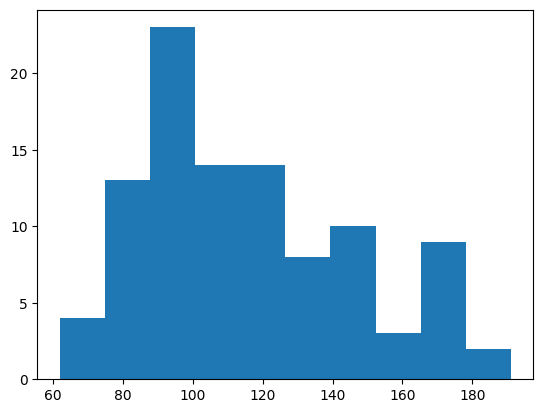

In [19]:
plt.hist(X['bpm'])

<BarContainer object of 100 artists>

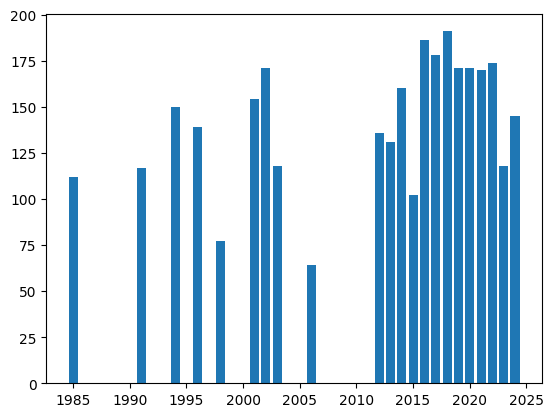

In [20]:
plt.bar(X['release_year'],X['bpm'])

{'whiskers': [<matplotlib.lines.Line2D at 0x11a4ef770>,
 'caps': [<matplotlib.lines.Line2D at 0x11a4efa10>,
 'boxes': [<matplotlib.lines.Line2D at 0x11a4ef620>],
 'medians': [<matplotlib.lines.Line2D at 0x11a4efcb0>],
 'fliers': [<matplotlib.lines.Line2D at 0x11a4efe00>],
 'means': []}

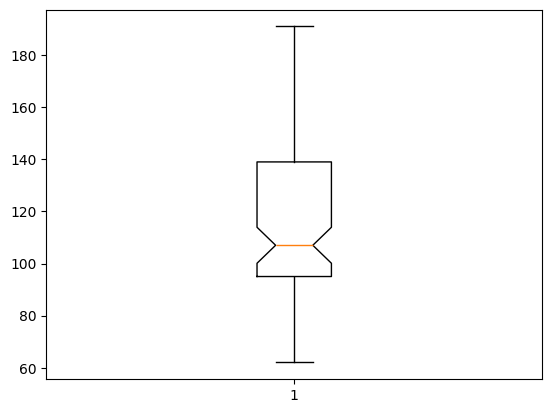

In [21]:
plt.boxplot(X['bpm'],notch=True,sym='gD')

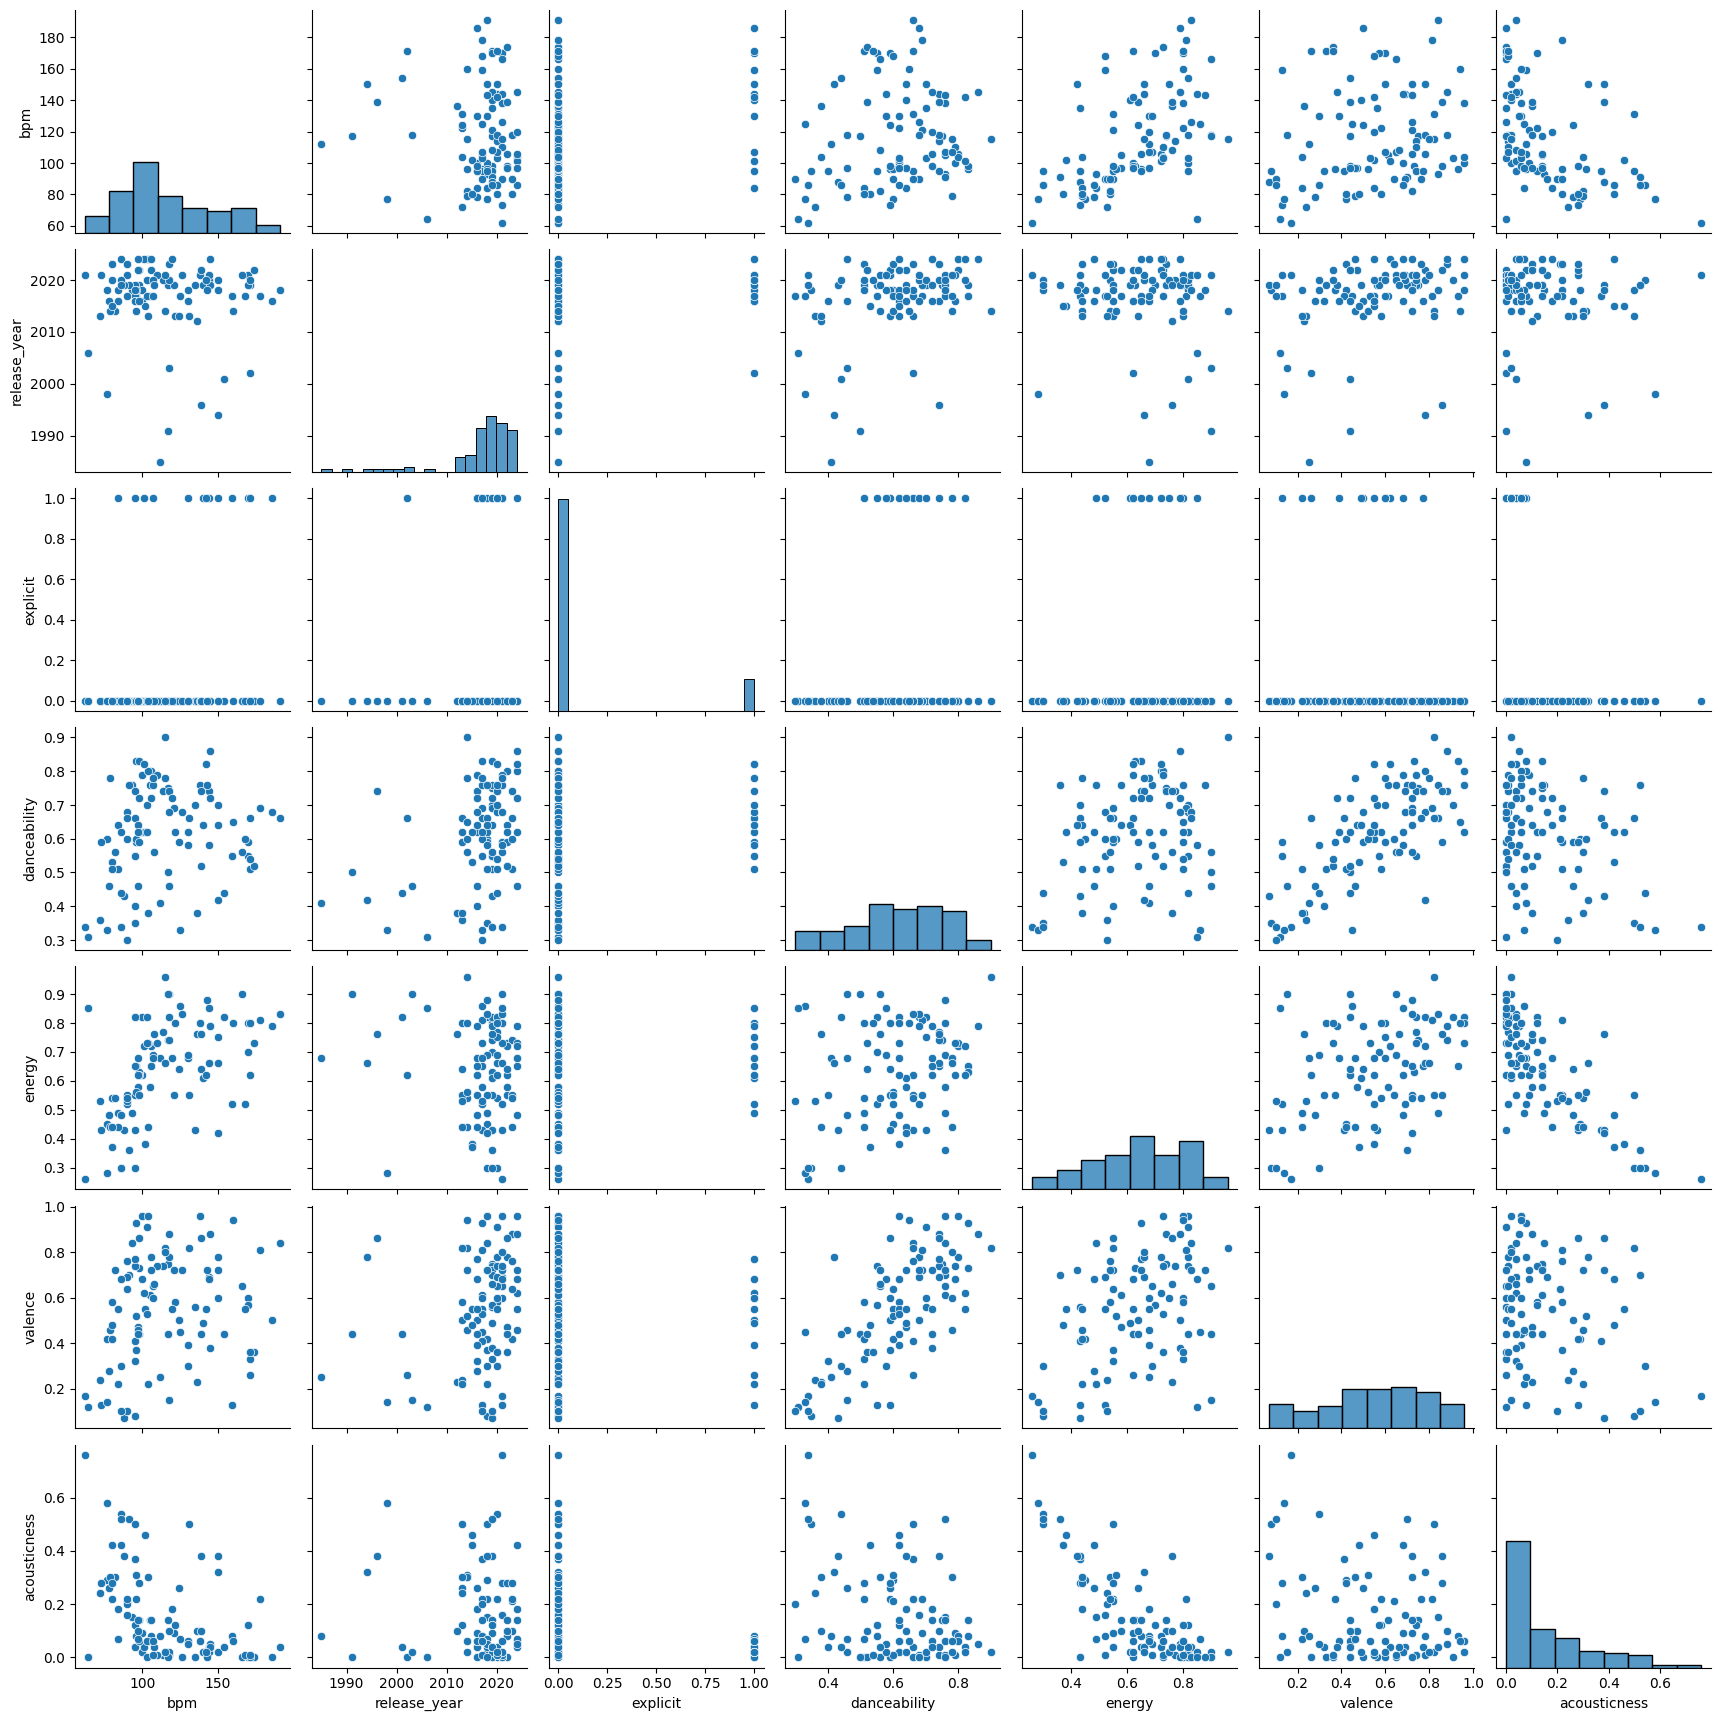

In [22]:
sns.pairplot(X)

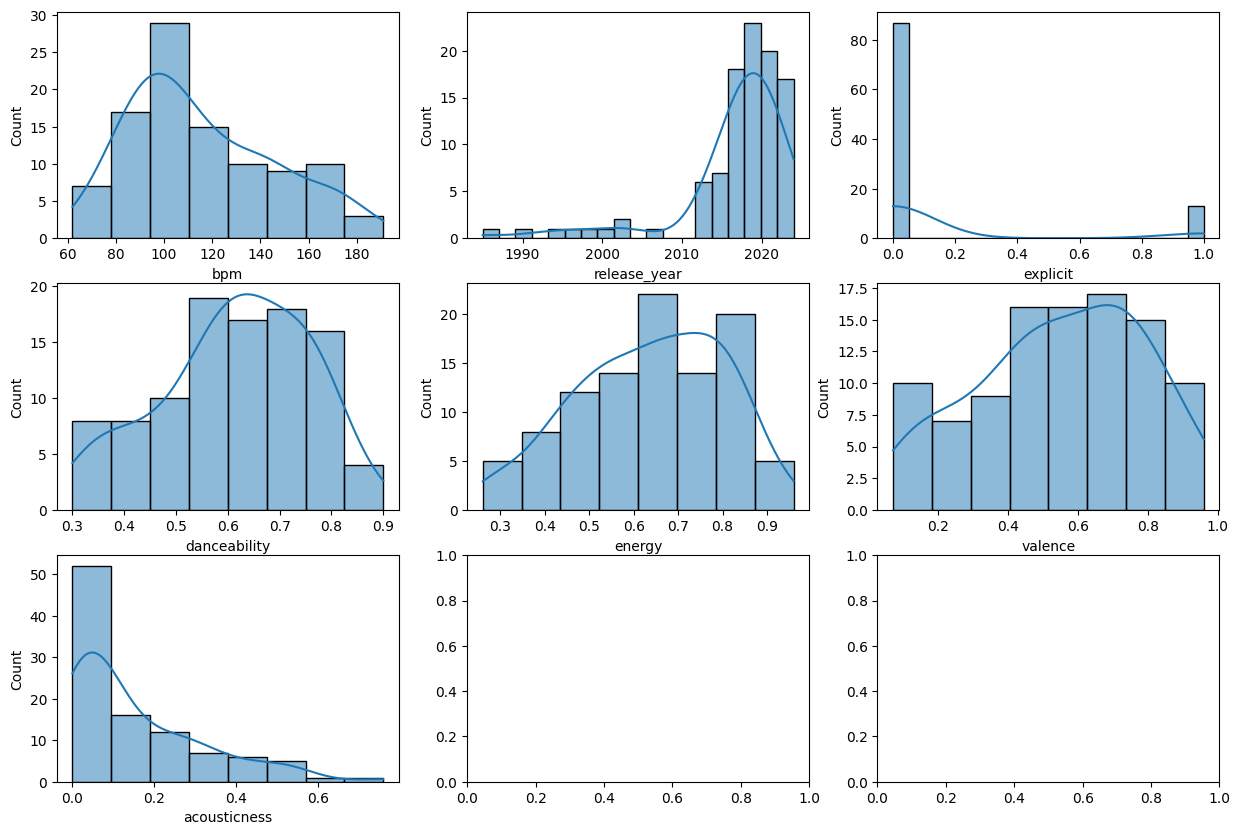

In [23]:
fig, axs = plt.subplots(3,3,figsize=(15, 10))
s = [x for x in np.ndindex((3,3))]
for i in range(7):
    sns.histplot(ax=axs[s[i]],x=X[X.columns[i]],kde=True)
 

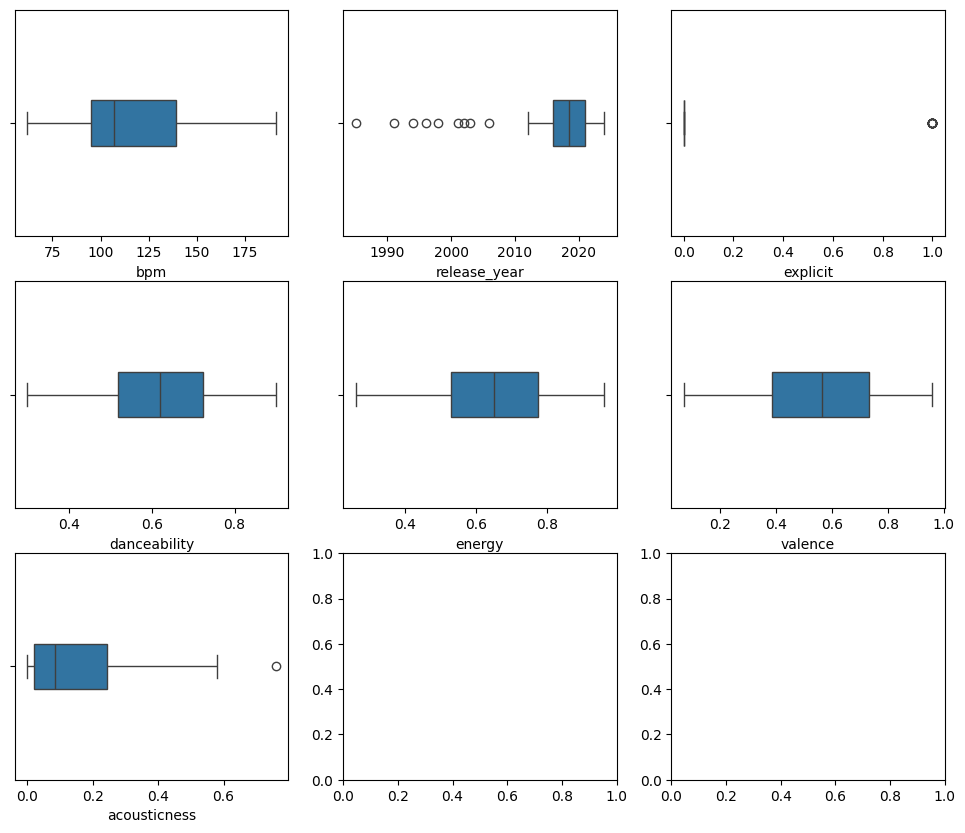

In [24]:
fig, axs = plt.subplots(3,3,figsize=(12, 10))
s = [x for x in np.ndindex((3,3))]
for i in range(7):
    sns.boxplot(ax=axs[s[i]],x=X[X.columns[i]],width=.2)

<Axes: xlabel='explicit', ylabel='count'>

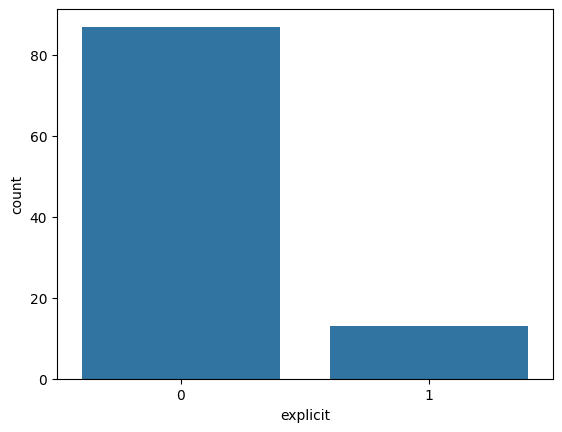

In [25]:
sns.countplot(X,x='explicit')

In [26]:
X.corr()

,bpm,release_year,explicit,danceability,energy,valence,acousticness
bpm,1.000000,-0.065521,0.267978,0.177505,0.541288,0.205954,-0.475695
release_year,-0.065521,1.000000,0.036383,0.336851,-0.087443,0.244145,-0.082268
explicit,0.267978,0.036383,1.000000,0.149437,0.093162,-0.093653,-0.283932
danceability,0.177505,0.336851,0.149437,1.000000,0.274988,0.723230,-0.346333
energy,0.541288,-0.087443,0.093162,0.274988,1.000000,0.402839,-0.772410
valence,0.205954,0.244145,-0.093653,0.723230,0.402839,1.000000,-0.258553
acousticness,-0.475695,-0.082268,-0.283932,-0.346333,-0.772410,-0.258553,1.000000


<Axes: >

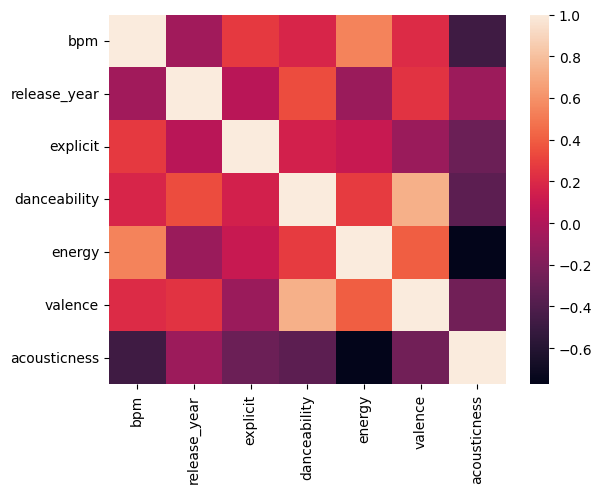

In [27]:
sns.heatmap(X.corr())

<Axes: xlabel='danceability', ylabel='valence'>

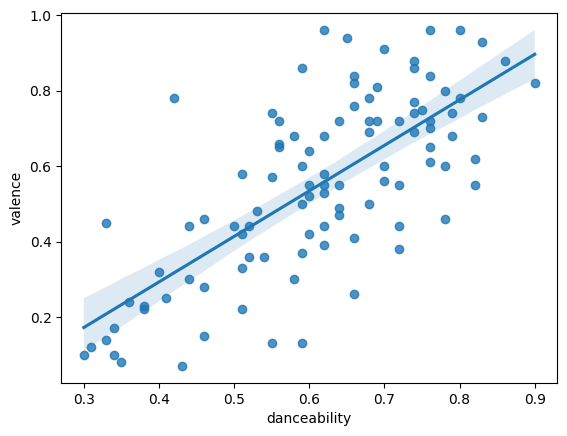

In [28]:
sns.regplot(X,x='danceability',y='valence')

<Axes: xlabel='energy', ylabel='acousticness'>

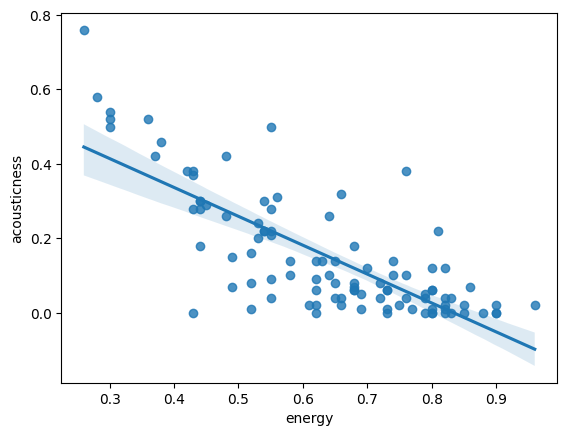

In [29]:
sns.regplot(X,x='energy',y='acousticness')

In [30]:
X

,bpm,release_year,explicit,danceability,energy,valence,acousticness
0,171,2019,0,0.51,0.80,0.33,0.00
1,96,2017,0,0.83,0.65,0.93,0.08
2,77,2018,0,0.60,0.45,0.42,0.29
3,93,2018,0,0.76,0.49,0.84,0.15
4,100,2016,0,0.79,0.62,0.68,0.09
...,...,...,...,...,...,...,...
95,143,2018,0,0.76,0.88,0.72,0.00
96,171,2020,0,0.54,0.80,0.36,0.01
97,150,2018,0,0.64,0.42,0.72,0.38
98,142,2020,1,0.82,0.62,0.55,0.02


In [31]:
X_train , X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3 , random_state = 42)

In [32]:
X.shape ,X_train.shape, X_test.shape

((100, 7), (70, 7), (30, 7))

In [33]:
y.shape, y_train.shape, y_test.shape

((100,), (70,), (30,))

In [34]:
model = LinearRegression()

In [35]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
y_pred = model.predict(X_test)

In [37]:
r2_score(y_test,y_pred)

-0.09576959902527249

In [38]:
mean_squared_error(y_test,y_pred)

0.9625363127537441

In [39]:
mean_squared_error(y_test,y_pred)**0.5

0.9810893500358385

## remembering i should check for corr between X and y lol

In [ ]:
Xmod = X
Xmod['y']=y

In [ ]:
sns.pairplot(Xmod)

In [ ]:
Xmod.corr()

In [ ]:
sns.regplot(Xmod,x='y',y='acousticness')

## so far the relationship between variables seem non linear, but i did demonstrate that a linear regression model would be terrible for this, with or without scaling 

In [40]:
scalar = StandardScaler()
X_train_scal = scalar.fit_transform(X_train)
X_test_scal = scalar.transform(X_test)

In [41]:
model2 = LinearRegression()
model2.fit(X_train_scal,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
y_pred2 = model2.predict(X_test_scal)

In [43]:
r2_score(y_test,y_pred2)

-0.09576959902527138

## trying decision tree, random forest

In [44]:
X_train , X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3 , random_state = 42)

In [45]:
t = tree.DecisionTreeRegressor()
t.fit(X_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [46]:
pred = t.predict(X_test)

In [47]:
r2_score(y_test,pred)

-0.960812836205164

In [48]:
mean_squared_error(y_test,pred)

1.7224000000000002

In [49]:
pred_train = t.predict(X_train)

In [50]:
r2_score(y_train,pred_train)

1.0

In [51]:
mean_squared_error(y_train,pred_train)

0.0

In [52]:
num_folds = 5
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

In [53]:
cross_val_score(t, X, y, cv=kf)

array([-0.79910647, -0.59965878, -0.54326738, -2.00269207,  0.22478342])

In [54]:
X

,bpm,release_year,explicit,danceability,energy,valence,acousticness
0,171,2019,0,0.51,0.80,0.33,0.00
1,96,2017,0,0.83,0.65,0.93,0.08
2,77,2018,0,0.60,0.45,0.42,0.29
3,93,2018,0,0.76,0.49,0.84,0.15
4,100,2016,0,0.79,0.62,0.68,0.09
...,...,...,...,...,...,...,...
95,143,2018,0,0.76,0.88,0.72,0.00
96,171,2020,0,0.54,0.80,0.36,0.01
97,150,2018,0,0.64,0.42,0.72,0.38
98,142,2020,1,0.82,0.62,0.55,0.02


In [55]:
from sklearn.ensemble import RandomForestRegressor

In [79]:
reg = RandomForestRegressor()

In [80]:
reg.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [81]:
rpred = reg.predict(X_test)

In [82]:
r2_score(y_test,rpred)

-0.026988347649373967

In [83]:
mean_squared_error(y_test,rpred)

0.902118089666667

## conlusion 

this dataset probably would work better for data analysis not ML(model predictions etc)